In [46]:
#importing important libraries..
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})
SEED = 42
np.random.seed(SEED)
print("Environment ready")

Environment ready


# Data quality assesment and primary observation...


In [47]:
#Loading the dataset: 
df = pd.read_csv("Churn_Modelling.csv")
print(df.shape)
print("---------------------------------")
print(df.info())
print("------------------------------------------------------")
print(df.describe().T)
print("------------------------------------------------------")
print(df.head())

(10000, 14)
---------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
-------------------------------------------

In [48]:

print(df.nunique())
print("------------------------------------------------------------")
print(df.columns)
print("--------------------------------------------------------------------------")
print(df.describe(include = "object").T)
print("---------------------------------------------------------------")
print(df.isnull().sum())
print("------------------------------------------------------------------------")
print(f"The number of duplicated values in the dataset is : {df.duplicated().sum()}")

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64
------------------------------------------------------------
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
--------------------------------------------------------------------------
           count unique     top  freq
Surname    10000   2932   Smith    32
Geography  10000      3  France  5014
Gender     10000      2    Male  5457
---------------------------------------------------------------
RowNumber          0
CustomerId         0
Surname           

# Explorary data analysis...

In [49]:
num_cols = df.select_dtypes(include = np.number).columns.tolist()
print("----------------------------------------------------------")
cat_cols = df.select_dtypes(include = "object").columns.tolist()
print(num_cols)
print(cat_cols)
print(df["Exited"].value_counts())

#normalizing the target column
print(df["Exited"].value_counts(normalize=True) * 100)



----------------------------------------------------------
['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
['Surname', 'Geography', 'Gender']
Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


# Data visualization...


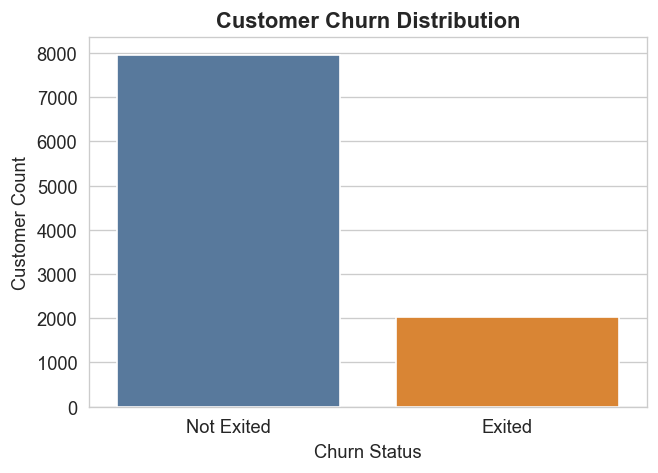

In [50]:
# Visualizing the target column...
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Exited",
    order=[0, 1],
    palette=["#4C78A8", "#F58518"],
)

plt.title("Customer Churn Distribution", fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")
ax.set_xticklabels(["Not Exited", "Exited"])
plt.savefig("Target Column distribution.png", bbox_inches="tight")

plt.show()

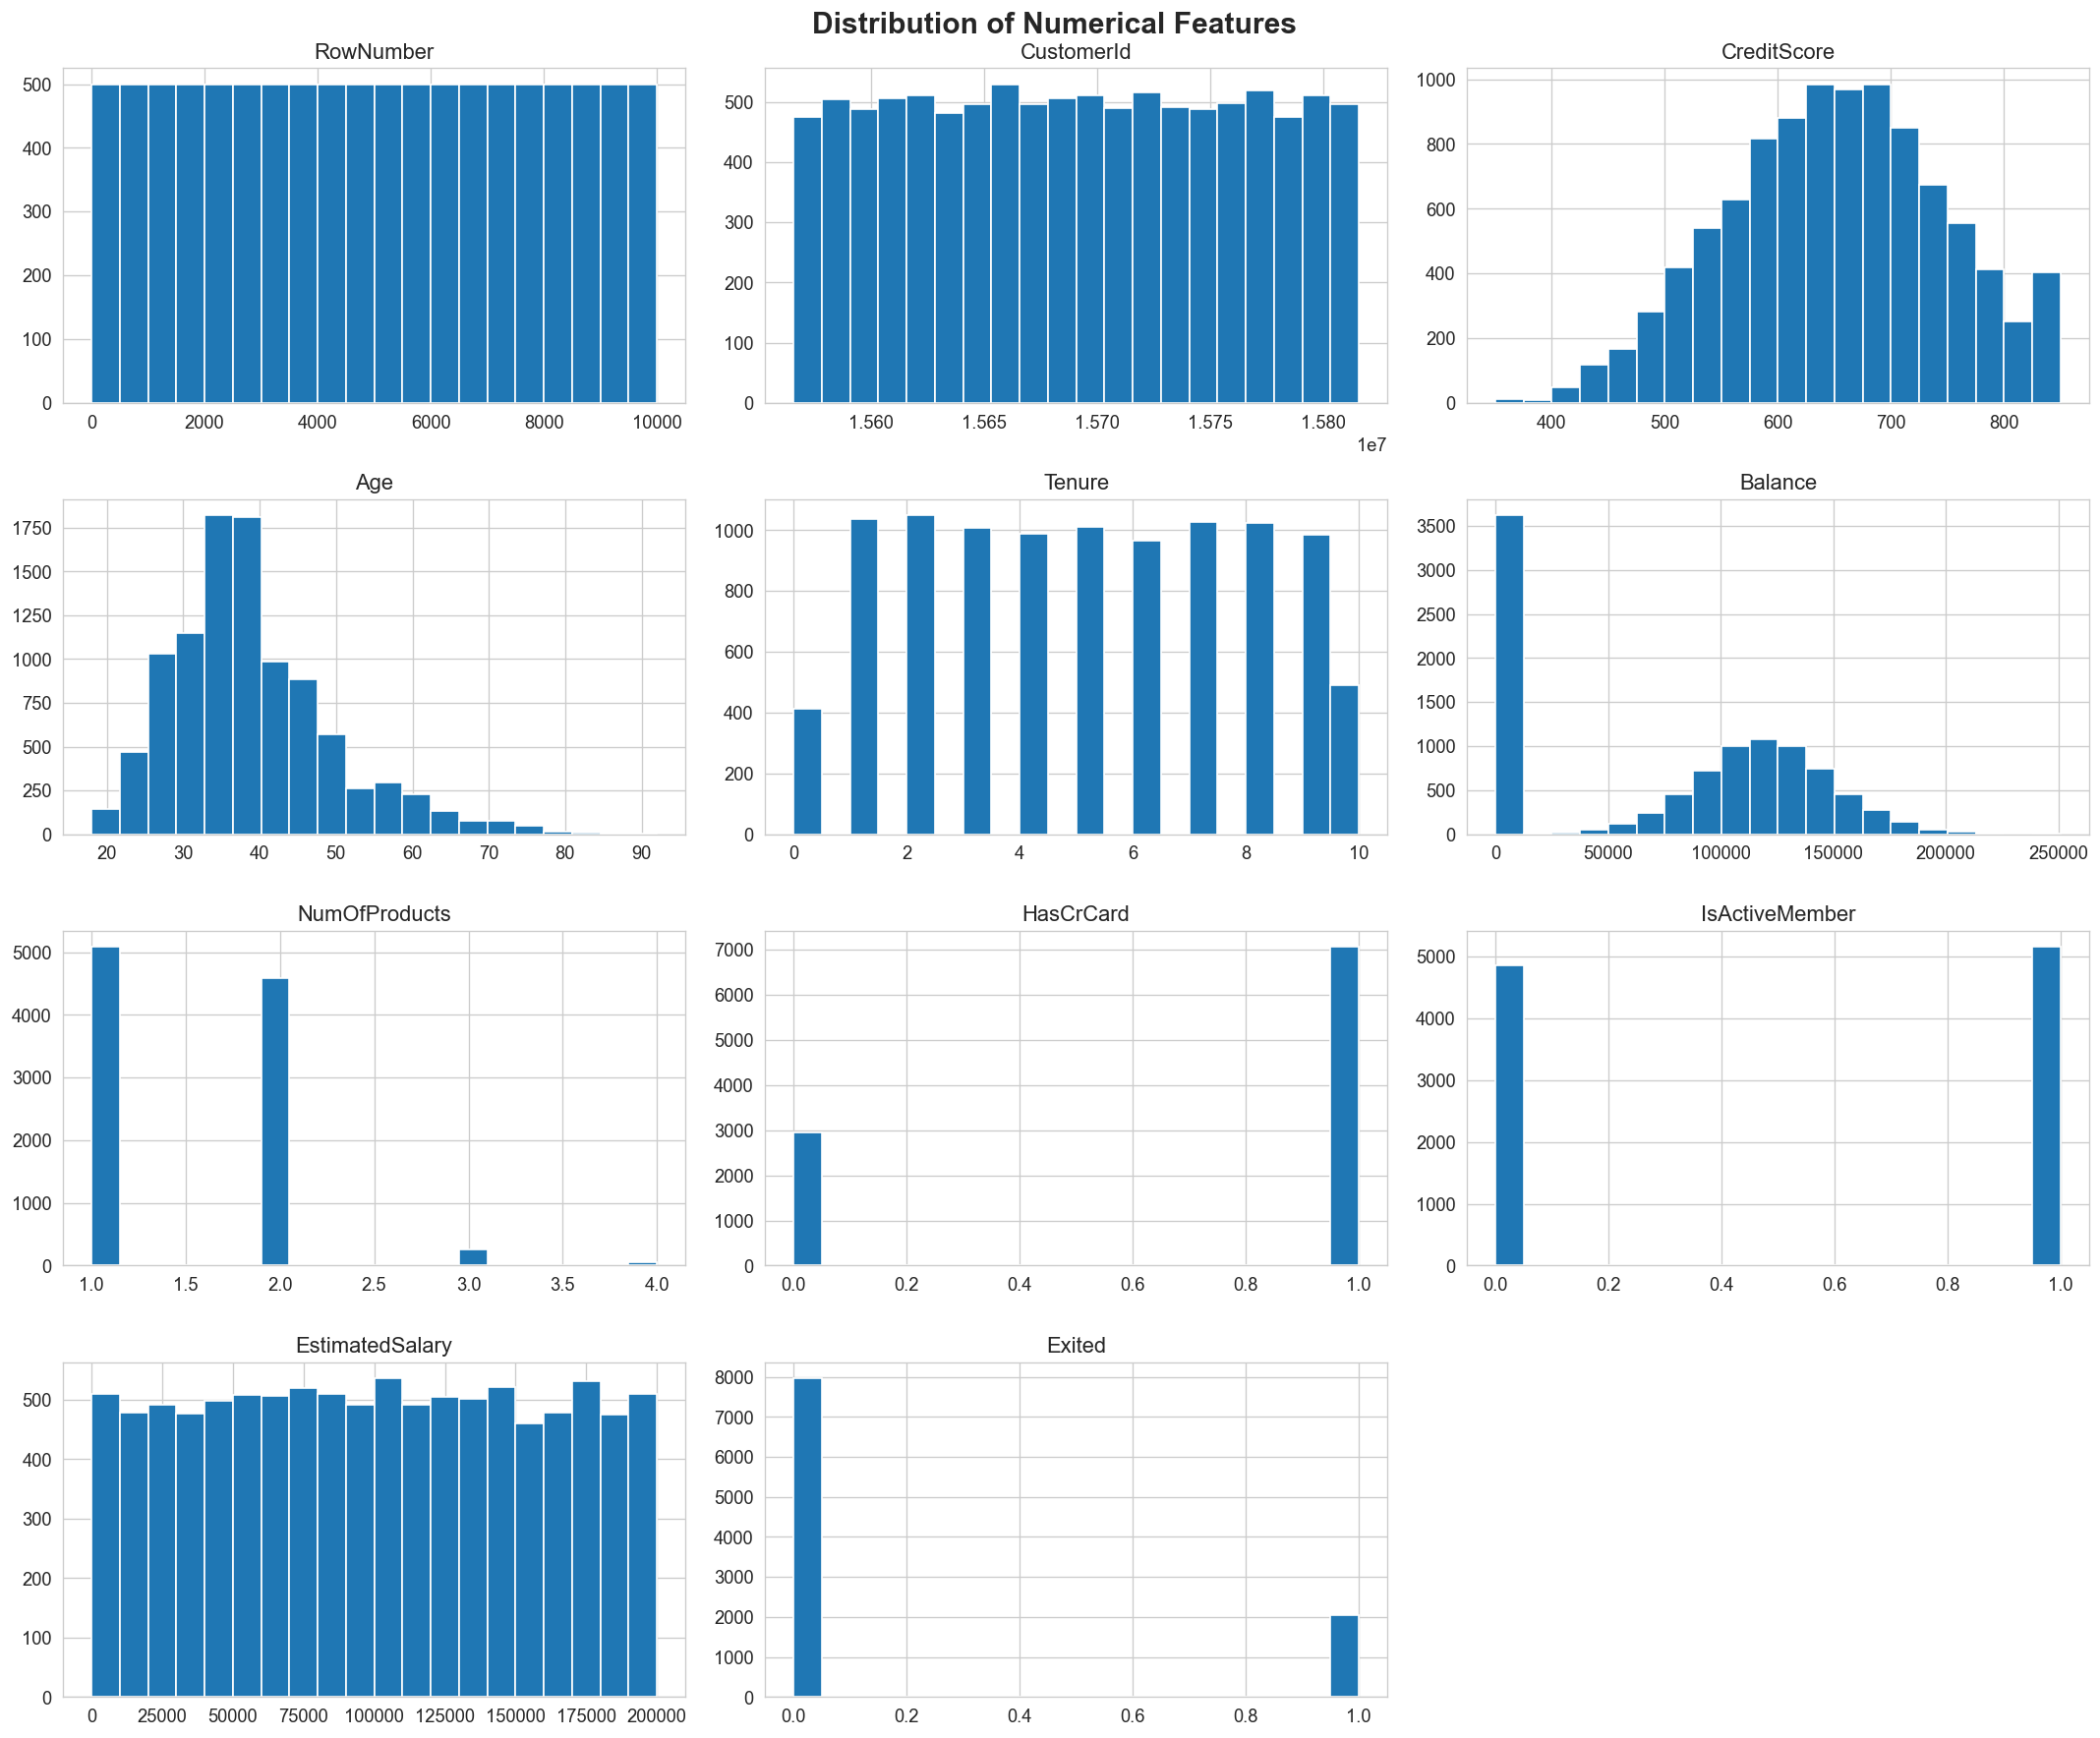

In [51]:
#Neumerical feature distribution...

df[num_cols].hist(
    figsize=(18,15),
    bins=20
)

plt.suptitle("Distribution of Numerical Features",
             fontsize=18,
             fontweight="bold",

              )
plt.savefig("Numerical Features .png", bbox_inches="tight")

plt.tight_layout()

plt.show()


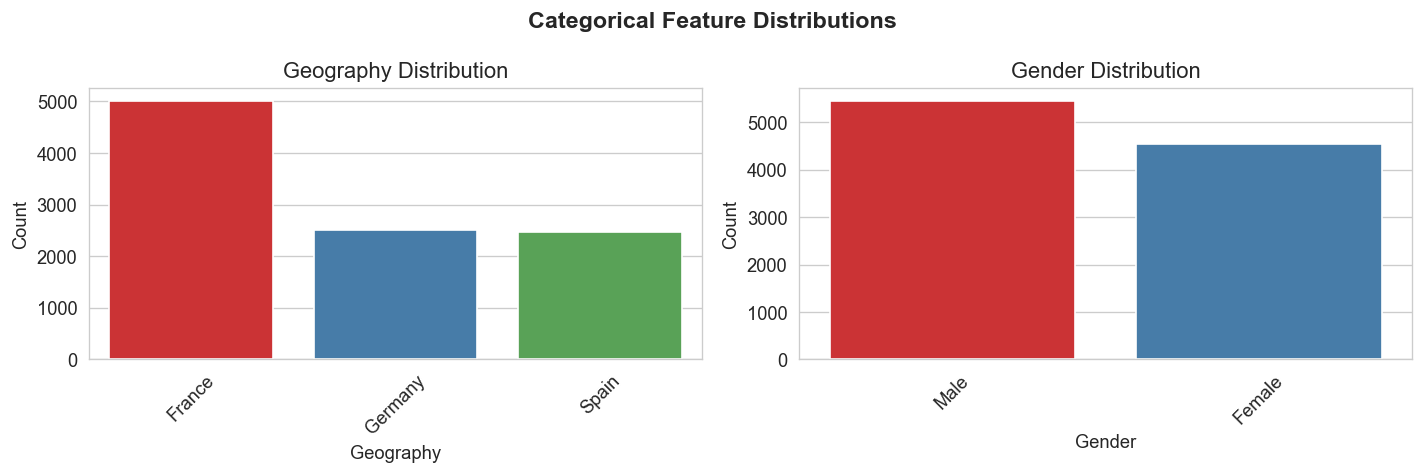

In [52]:
# Visualizing the categorical features...
categorical_cols = [col for col in ["Geography", "Gender"] if col in df.columns]

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(12, 4))

if len(categorical_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax, palette="Set1")
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Categorical Features.png", bbox_inches="tight")
plt.show()

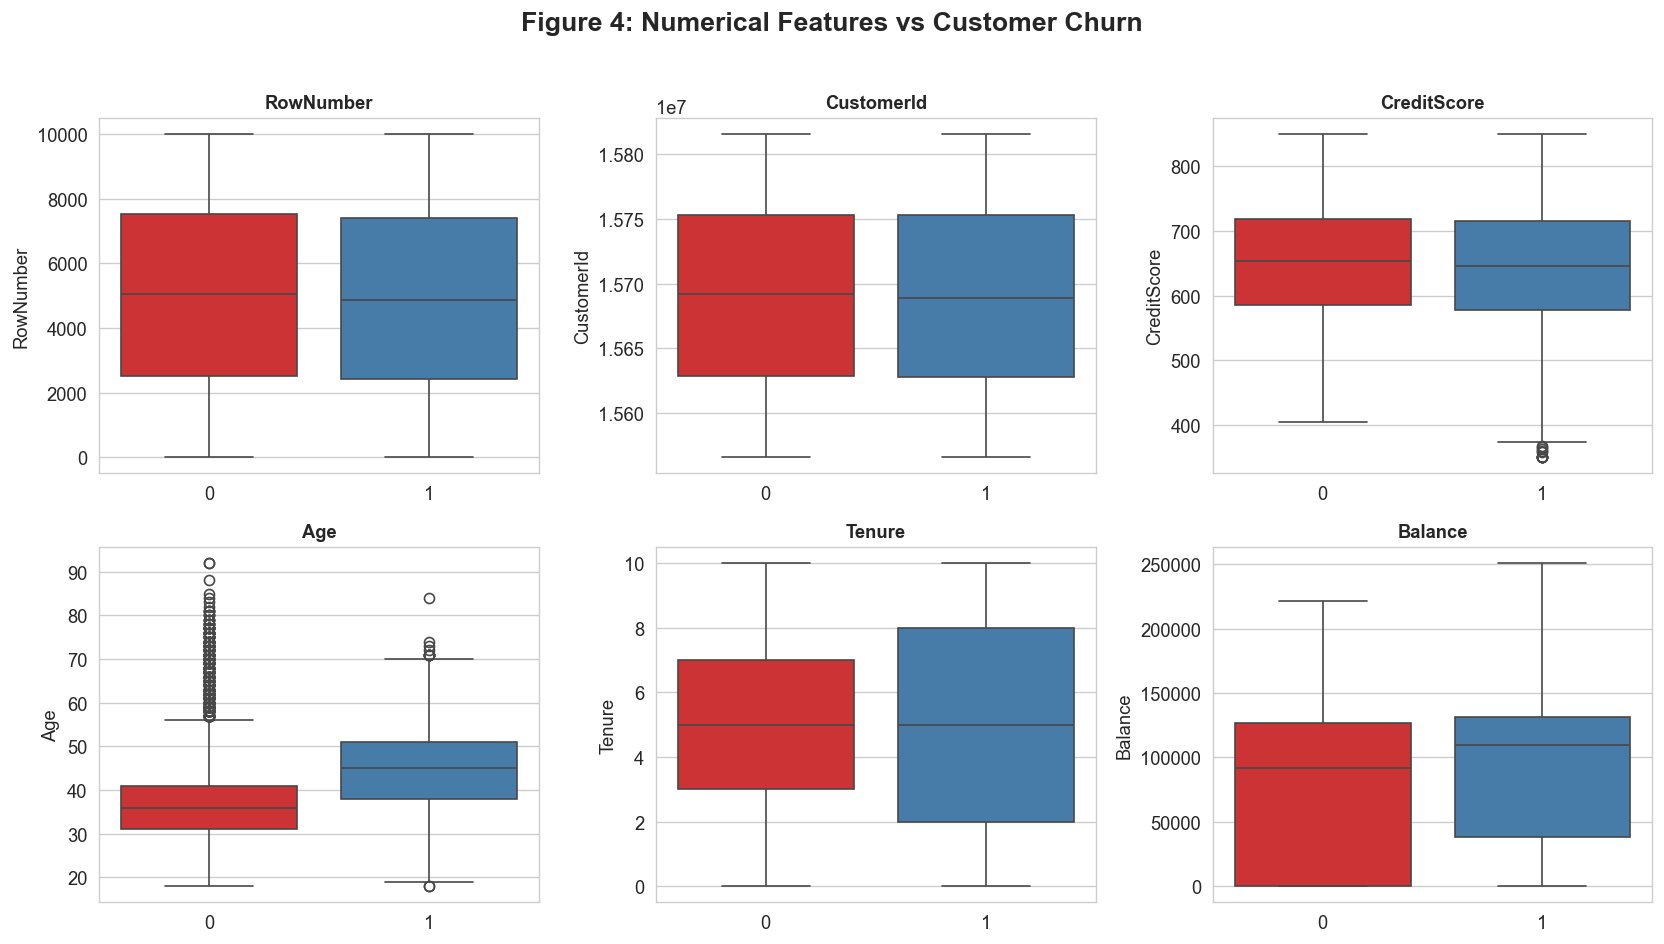

In [53]:
#Neumerical feature vs target column distribution...
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):

    sns.boxplot(
        data=df,
        x="Exited",
        y=col,
        ax=ax,
        palette="Set1"
    )

    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(col)

# Hide unused axes
for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(
    "Figure 4: Numerical Features vs Customer Churn",
    fontsize=16,
    fontweight="bold"
)
plt.savefig("Numerical Features vs Customer churn.png", bbox_inches="tight")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

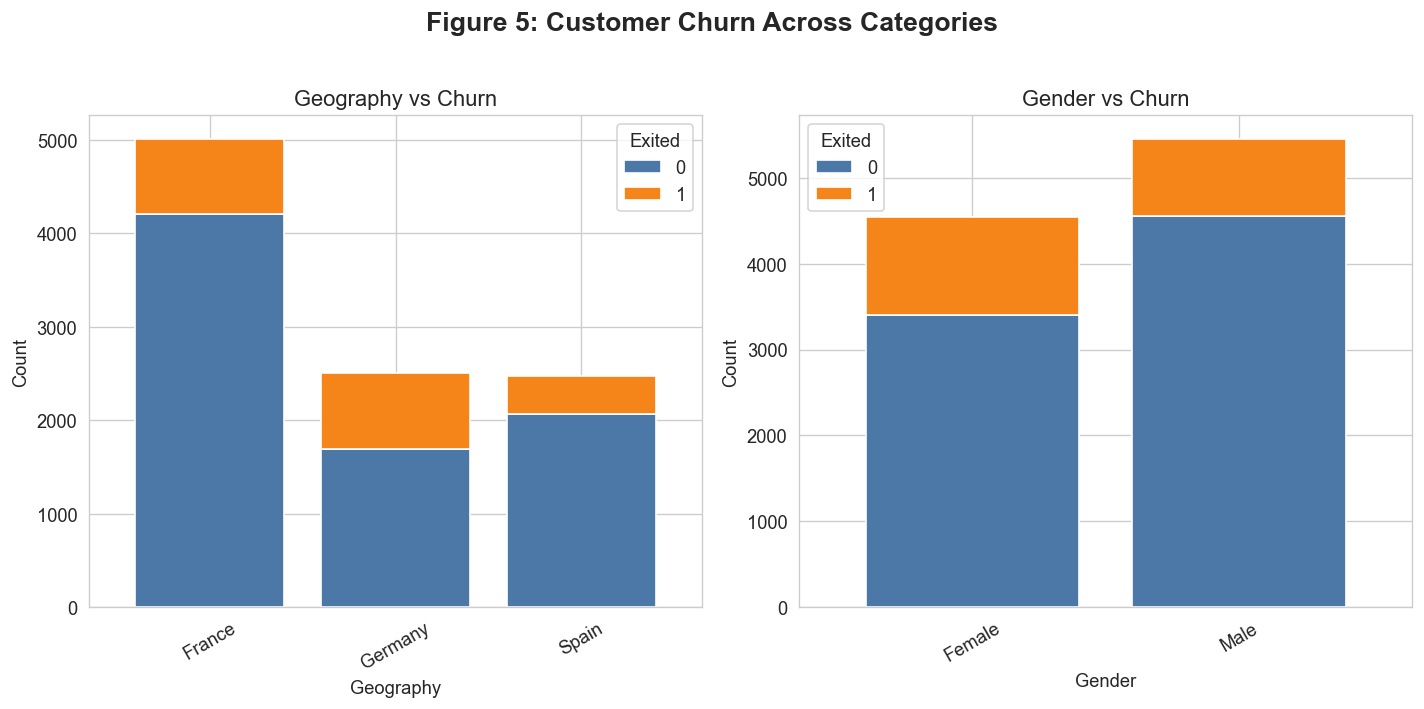

In [54]:
#Catagorical feature vs target column distribution...
plot_cols = [col for col in ["Geography", "Gender"] if col in df.columns]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(12, 6))

if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    counts = pd.crosstab(df[col], df["Exited"])
    counts.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=["#4C78A8", "#F58518"],
        width=0.8
    )
    ax.set_title(f"{col} vs Churn")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Exited")

plt.suptitle("Figure 5: Customer Churn Across Categories", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

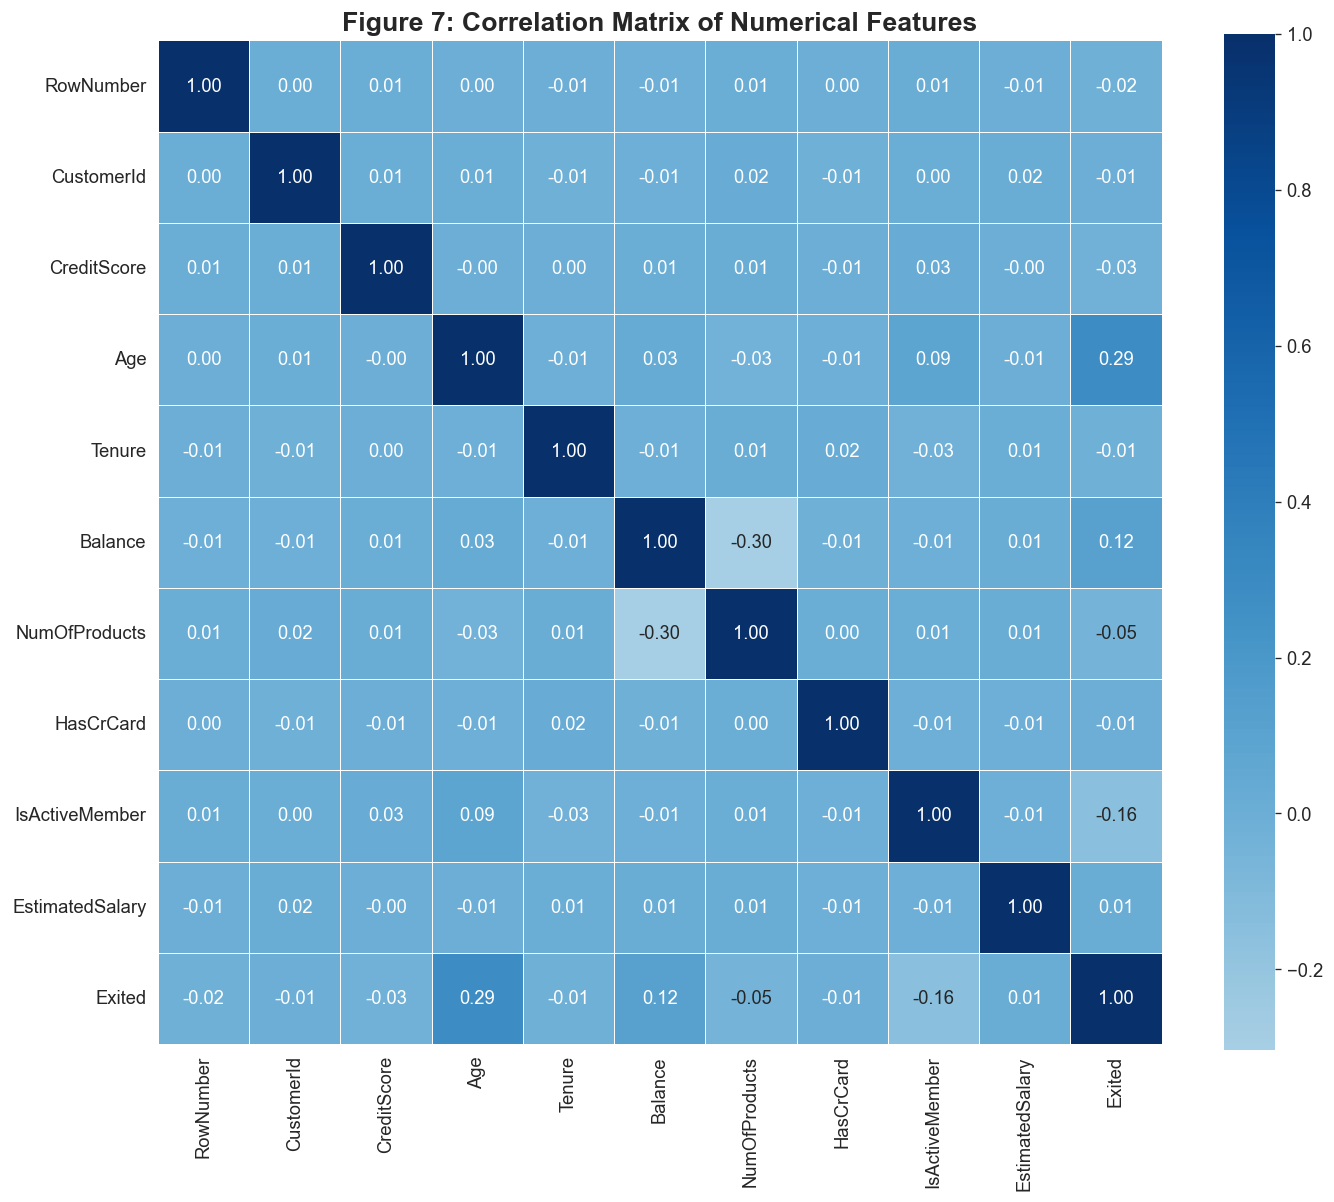

In [55]:
#corellation heatmap
# ==========================================
# Figure 7 : Correlation Heatmap
# ==========================================

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="Blues",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title(
    "Figure 7: Correlation Matrix of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Feature Engineering..


In [56]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)

df["BalanceSalaryRatio"] = (
    df["Balance"] /
    (df["EstimatedSalary"] + 1)
)
df["BalancePerProduct"] = (
    df["Balance"] /
    (df["NumOfProducts"] + 1)
)
df["ActiveProducts"] = (
    df["IsActiveMember"] *
    df["NumOfProducts"]
)
drop_cols = [
    "RowNumber",
    "CustomerId",
    "Surname"
]

print(df.head().T)

                            0          1          2         3          4
RowNumber                   1          2          3         4          5
CustomerId           15634602   15647311   15619304  15701354   15737888
Surname              Hargrave       Hill       Onio      Boni   Mitchell
CreditScore               619        608        502       699        850
Geography              France      Spain     France    France      Spain
Gender                 Female     Female     Female    Female     Female
Age                        42         41         42        39         43
Tenure                      2          1          8         1          2
Balance                   0.0   83807.86   159660.8       0.0  125510.82
NumOfProducts               1          1          3         2          1
HasCrCard                   1          0          1         0          1
IsActiveMember              1          1          0         0          1
EstimatedSalary     101348.88  112542.58  113931.57

In [57]:
#X, Y split..
X = df.drop(columns="Exited")

y = df["Exited"]

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [59]:
#lead free preprocessing pipeline.. 
num_colsX = X_train.select_dtypes(include="number").columns

cat_colsX = X_train.select_dtypes(exclude="number").columns


numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_colsX),
    ("cat", categorical_pipe, cat_colsX),
])
def build_pipeline(model, use_smote=False):

    if use_smote:
        return ImbPipeline([
            ("prep", preprocessor),
            ("smote", SMOTE(random_state=SEED)),
            ("model", model)
        ])

    return Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
print("Numeric:", num_colsX)
print("Categorical:", cat_colsX)
print(df.head().T)

Numeric: Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'BalanceSalaryRatio', 'BalancePerProduct', 'ActiveProducts'],
      dtype='object')
Categorical: Index(['Surname', 'Geography', 'Gender'], dtype='object')
                            0          1          2         3          4
RowNumber                   1          2          3         4          5
CustomerId           15634602   15647311   15619304  15701354   15737888
Surname              Hargrave       Hill       Onio      Boni   Mitchell
CreditScore               619        608        502       699        850
Geography              France      Spain     France    France      Spain
Gender                 Female     Female     Female    Female     Female
Age                        42         41         42        39         43
Tenure                      2          1          8         1          2
Balance              

In [60]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
    "KNN (k=7)":           KNeighborsClassifier(n_neighbors=7),
    "SVM (RBF)":           SVC(kernel="rbf", C=10, gamma="scale", probability=True,
                               class_weight="balanced", random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=1000, class_weight="balanced",
                                                  n_jobs=-1, random_state=SEED),
    "XGBoost":             xgb.XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=5,
                                             subsample=0.9, colsample_bytree=0.9,
                                             tree_method="hist", eval_metric="mlogloss",
                                             n_jobs=-1, random_state=SEED),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, max_depth=5,
                                              class_weight="balanced", n_jobs=-1,
                                              random_state=SEED, verbose=-1),
    "CatBoost":            CatBoostClassifier(iterations=1000, learning_rate=0.05, depth=5,
                                              verbose=0, random_state=SEED),
}
print(f"{len(models)} models defined")

7 models defined


## . 5-fold Stratified Cross-Validation (headline results)

Each model is evaluated with the full preprocessing pipeline re-fit per fold.
We report **mean ± std** across folds so you can see which gaps are real vs. noise.


In [61]:
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=SEED)
scoring = {
    "Accuracy":  "accuracy",
    "Precision": "precision_macro",
    "Recall":    "recall",
    "F1":        "f1",
    "AUC":       "roc_auc",
}

rows = []
for name, mdl in models.items():
    t0 = time.time()
    cvres = cross_validate(build_pipeline(mdl), X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"Model": name}
    for label in scoring:
        m, s = cvres[f"test_{label}"].mean(), cvres[f"test_{label}"].std()
        row[label] = f"{m:.3f} ± {s:.3f}"
        row[f"_{label}"] = m          # numeric copy for sorting/plotting
    row["Time (s)"] = round(time.time() - t0, 2)
    rows.append(row)
    print(f"  done: {name}")

results_df = (pd.DataFrame(rows)
              .sort_values("_F1", ascending=False)
              .reset_index(drop=True))
display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC", "Time (s)"]
print("\nTABLE I — 5-fold CV (mean ± std)")
display(results_df[display_cols])

  done: Logistic Regression
  done: KNN (k=7)
  done: SVM (RBF)
  done: Random Forest
  done: XGBoost
  done: LightGBM
  done: CatBoost

TABLE I — 5-fold CV (mean ± std)


,Model,Accuracy,Precision,Recall,F1,AUC,Time (s)
0,LightGBM,0.830 ± 0.008,0.739 ± 0.013,0.606 ± 0.036,0.593 ± 0.026,0.840 ± 0.018,6.04
1,XGBoost,0.853 ± 0.012,0.791 ± 0.023,0.479 ± 0.040,0.570 ± 0.040,0.846 ± 0.021,8.37
2,CatBoost,0.858 ± 0.009,0.811 ± 0.017,0.456 ± 0.037,0.566 ± 0.036,0.864 ± 0.013,21.54
3,SVM (RBF),0.836 ± 0.007,0.749 ± 0.012,0.525 ± 0.033,0.566 ± 0.024,0.819 ± 0.017,20.22
4,Logistic Regression,0.717 ± 0.012,0.629 ± 0.015,0.602 ± 0.035,0.464 ± 0.025,0.736 ± 0.022,5.06
5,Random Forest,0.848 ± 0.006,0.843 ± 0.013,0.314 ± 0.023,0.457 ± 0.027,0.852 ± 0.015,44.25
6,KNN (k=7),0.832 ± 0.011,0.764 ± 0.032,0.339 ± 0.033,0.451 ± 0.040,0.788 ± 0.020,4.36


In [62]:
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=SEED)
scoring = {
    "Accuracy":  "accuracy",
    "Precision": "precision_macro",
    "Recall":    "recall",
    "F1":        "f1",
    "AUC":       "roc_auc",
}

rows = []
for name, mdl in models.items():
    t0 = time.time()
    cvres = cross_validate(build_pipeline(mdl, use_smote=True), X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"Model": name}
    for label in scoring:
        m, s = cvres[f"test_{label}"].mean(), cvres[f"test_{label}"].std()
        row[label] = f"{m:.3f} ± {s:.3f}"
        row[f"_{label}"] = m          # numeric copy for sorting/plotting
    row["Time (s)"] = round(time.time() - t0, 2)
    rows.append(row)
    print(f"  done: {name}")

results_df = (pd.DataFrame(rows)
              .sort_values("_F1", ascending=False)
              .reset_index(drop=True))
display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC", "Time (s)"]
print("\nTABLE I — 5-fold CV (mean ± std)")
display(results_df[display_cols])

  done: Logistic Regression
  done: KNN (k=7)
  done: SVM (RBF)
  done: Random Forest
  done: XGBoost
  done: LightGBM
  done: CatBoost

TABLE I — 5-fold CV (mean ± std)


,Model,Accuracy,Precision,Recall,F1,AUC,Time (s)
0,CatBoost,0.853 ± 0.008,0.780 ± 0.012,0.555 ± 0.033,0.606 ± 0.027,0.861 ± 0.013,44.19
1,XGBoost,0.850 ± 0.010,0.776 ± 0.017,0.523 ± 0.038,0.586 ± 0.033,0.855 ± 0.015,10.15
2,LightGBM,0.850 ± 0.010,0.778 ± 0.019,0.515 ± 0.028,0.583 ± 0.029,0.849 ± 0.018,6.05
3,Random Forest,0.852 ± 0.012,0.791 ± 0.024,0.462 ± 0.043,0.559 ± 0.043,0.849 ± 0.013,68.79
4,SVM (RBF),0.837 ± 0.008,0.752 ± 0.015,0.499 ± 0.038,0.555 ± 0.030,0.807 ± 0.020,47.12
5,KNN (k=7),0.697 ± 0.013,0.648 ± 0.012,0.760 ± 0.035,0.505 ± 0.019,0.789 ± 0.021,2.92
6,Logistic Regression,0.724 ± 0.014,0.626 ± 0.016,0.560 ± 0.031,0.453 ± 0.026,0.728 ± 0.020,1.32


## . Hyperparameter tuning on the best model

Light `GridSearchCV` over the top model from CV. On a dataset this small the gains
are modest — the grid is intentionally compact to avoid overfitting the CV.


In [63]:
best_name = results_df.iloc[0]["Model"]
print("Best model from CV:", best_name)

param_grids = {
    "Logistic Regression": {"model__C": [0.1, 0.5, 1, 2, 5]},
    "SVM (RBF)":           {"model__C": [1, 5, 10, 20], "model__gamma": ["scale", 0.01, 0.1]},
    "Random Forest":       {"model__n_estimators": [300, 500, 700, 1000],
                            "model__max_depth": [None, 6, 10],
                            "model__min_samples_leaf": [1, 2, 4,5,7]},
    "KNN (k=7)":           {"model__n_neighbors": [3, 5, 7, 9, 11]},
    "XGBoost":             {"model__max_depth": [3, 4, 5,7,9,10], "model__learning_rate": [0.03, 0.05, 0.1]},
    "LightGBM":            {"model__max_depth": [3, 4, 5,7,9,10], "model__learning_rate": [0.03, 0.05, 0.1]},
    "CatBoost":            {"model__depth": [3, 4, 5], "model__learning_rate": [0.03, 0.05, 0.1]},
}

grid = param_grids.get(best_name, {})
best_pipe = build_pipeline(models[best_name])

if grid:
    search = GridSearchCV(best_pipe, grid, cv=cv, scoring="f1_macro", n_jobs=-1)
    search.fit(X, y)
    best_pipe = search.best_estimator_
    print("Best params:", search.best_params_)
    print(f"Tuned CV macro-F1: {search.best_score_:.4f}")
else:
    print("No grid defined; using default best pipeline.")

Best model from CV: CatBoost
Best params: {'model__depth': 5, 'model__learning_rate': 0.05}
Tuned CV macro-F1: 0.7531


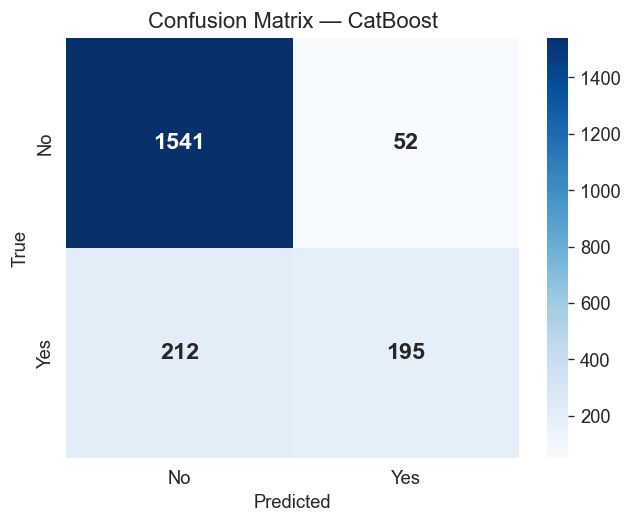

Classification report — CatBoost
              precision    recall  f1-score   support

          No       0.88      0.97      0.92      1593
         Yes       0.79      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [64]:

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
labels = ["No", "Yes"]
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size":14,"fontweight":"bold"}
)
ax.set(xlabel="Predicted", ylabel="True",
       title=f"Confusion Matrix — {best_name}")
plt.tight_layout(); plt.savefig("fig_confusion.png", bbox_inches="tight"); plt.show()

print(f"Classification report — {best_name}")
labels = ["No", "Yes"]

print(classification_report(
    y_test,
    y_pred,
    target_names=labels
))

# Mutual information of best features..

,Feature,MI Score
0,NumOfProducts,0.075086
1,Age,0.073009
2,ActiveProducts,0.040895
3,IsActiveMember,0.016602
4,BalancePerProduct,0.011162
5,Balance,0.009944
6,Geography_Germany,0.009858
7,Gender_Male,0.009407
8,BalanceSalaryRatio,0.008984
9,EstimatedSalary,0.002709


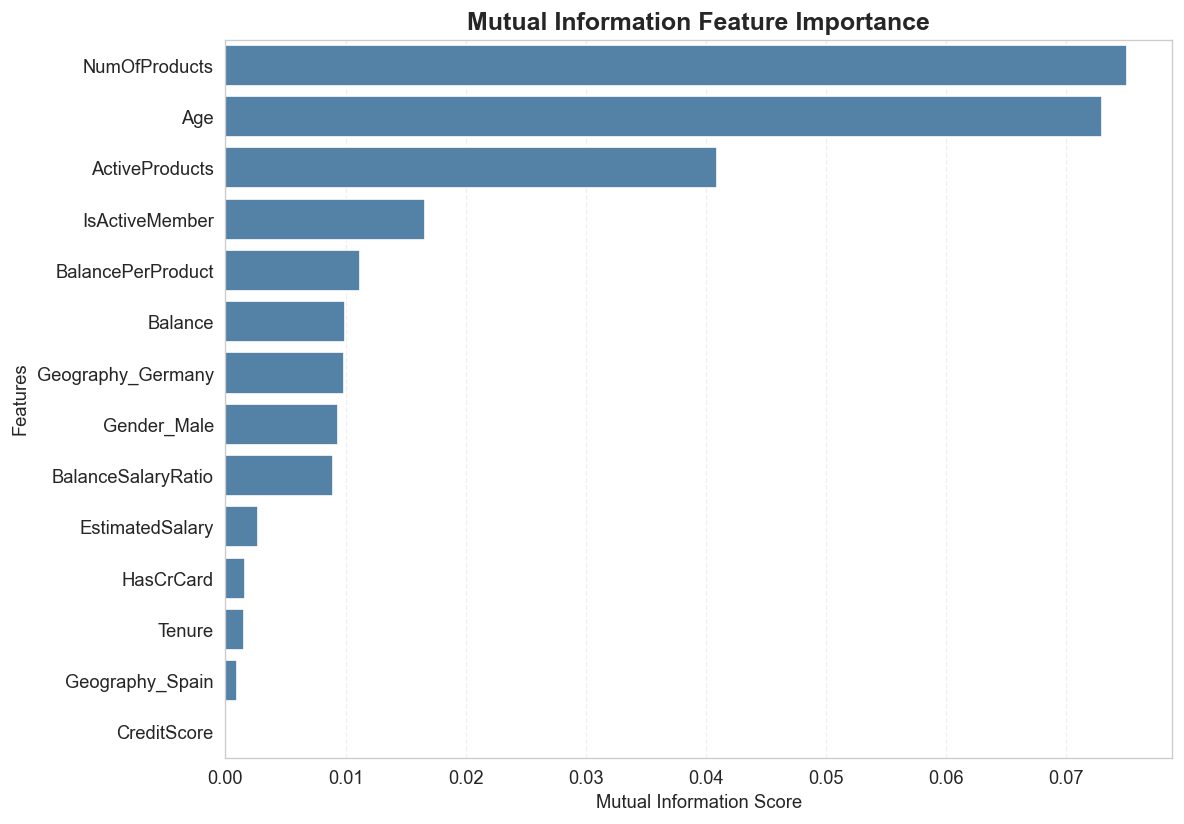

In [65]:
# ==========================================================
# Mutual Information Feature Importance
# ==========================================================

from sklearn.feature_selection import mutual_info_classif

# -----------------------------
# Features and Target
# -----------------------------

X_mi = df.drop(columns=["Exited"])
y_mi = df["Exited"]

# -----------------------------
# Remove Identifier Columns
# -----------------------------

drop_cols = ["RowNumber", "CustomerId", "Surname"]

X_mi = X_mi.drop(columns=drop_cols)

# -----------------------------
# One-Hot Encode Categorical Features
# -----------------------------

X_mi = pd.get_dummies(
    X_mi,
    drop_first=True
)

# -----------------------------
# Compute Mutual Information
# -----------------------------

mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42
)

# -----------------------------
# Create DataFrame
# -----------------------------

mi_df = (
    pd.DataFrame({
        "Feature": X_mi.columns,
        "MI Score": mi_scores
    })
    .sort_values(by="MI Score", ascending=False)
    .reset_index(drop=True)
)

# Display Scores
display(mi_df)

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(10,7))

sns.barplot(
    data=mi_df,
    x="MI Score",
    y="Feature",
    color="steelblue"
)

plt.title(
    "Mutual Information Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Features")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Mutual Information Feature Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

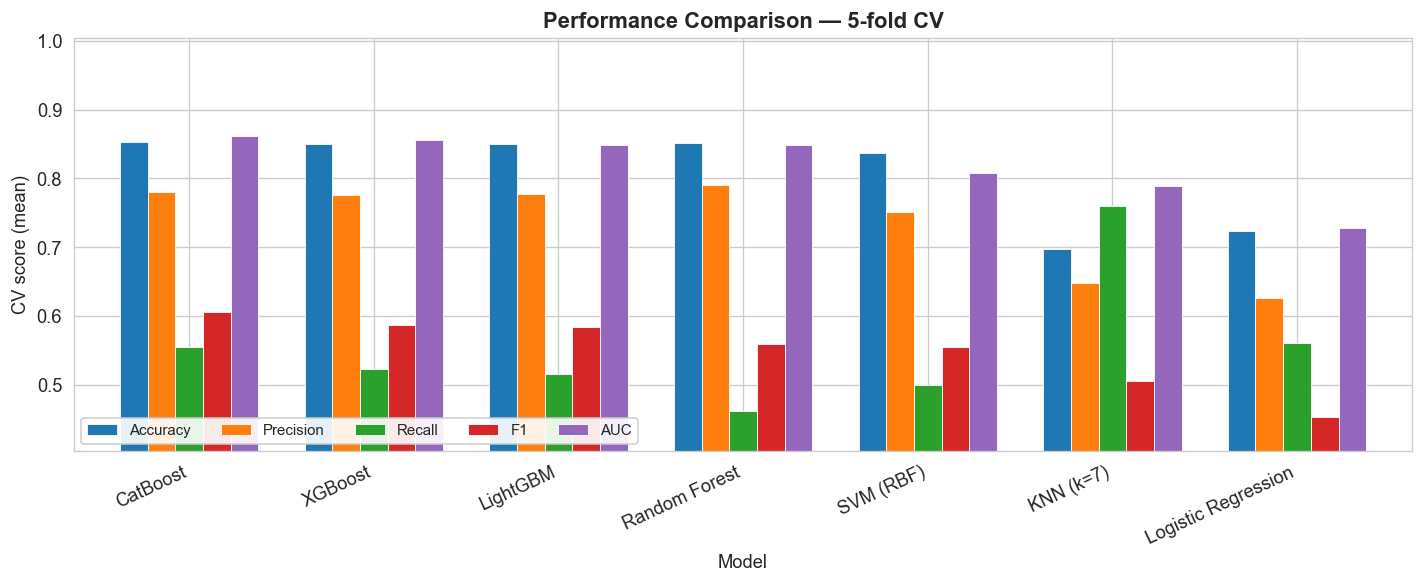

In [66]:
metric_cols = ["_Accuracy", "_Precision", "_Recall", "_F1", "_AUC"]
plot_df = results_df.set_index("Model")[metric_cols]
plot_df.columns = [c[1:] for c in metric_cols]

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.plot(kind="bar", ax=ax, width=0.75, edgecolor="white", linewidth=0.5)
ax.set_ylim(max(0, plot_df.values.min() - 0.05), 1.005)
ax.set_ylabel("CV score (mean)")
ax.set_title("Performance Comparison — 5-fold CV", fontweight="bold")
ax.legend(loc="lower left", fontsize=9, ncol=5, framealpha=0.9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout(); plt.savefig("fig_comparison.png", bbox_inches="tight"); plt.show()